# Clustering

## Theory Questions

### Q.1. What is unsupervised learning in the context of machine learning?

--> Unsupervised learning is a type of machine learning where the model is trained on unlabeled data.

There is no target/output variable. The algorithm tries to discover hidden patterns, structures, or groupings in the data.

### Q.2. How does K-Means clustering algorithm work?

--> K-Means is a centroid-based clustering algorithm.

STEP-1: Choose number of clusters K.

STEP-2: Randomly initialize K centroids.

STEP-3: Assign each data point to the nearest centroid (Euclidean distance).

STEP-4: Recalculate centroids as the mean of assigned points.

STEP-5: Repeat steps 3 and 4 until centroids stop changing.

With GOAL to minimize within-cluster variance (inertia).

### Q.3. Explain the concept of a dendrogram in hierarchical clustering.

--> A dendrogram is a tree-like diagram that shows how clusters are formed in hierarchical clustering.

Leaves represent individual data points.

Branches represent cluster merges.

Height of the merge represents distance between clusters.

It helps determine the optimal number of clusters by cutting the tree at a chosen height.

### Q.4. What is the main difference between K-Means and Hierarchical Clustering?

| K-Means                     | Hierarchical Clustering      |
| --------------------------- | ---------------------------- |
| Requires pre-defined K      | Does not require K initially |
| Flat clustering             | Produces hierarchy (tree)    |
| Fast for large datasets     | Computationally expensive    |
| Sensitive to initialization | No random initialization     |


### Q.5. What are the advantages of DBSCAN over K-Means?

--> DBSCAN:

Does not require specifying number of clusters.

Can detect arbitrarily shaped clusters.

Identifies noise/outliers.

Works well with clusters of varying density.

K-Means assumes spherical clusters and struggles with noise.

### Q.6. When would you use Silhouette Score in clustering?

--> Silhouette Score is used to:

Evaluate clustering quality.

Determine optimal number of clusters.

Measure how well a data point fits in its cluster.

Value range: -1 to 1

Higher value = better clustering.

### Q.7. What are the limitations of Hierarchical Clustering?

--> High computational cost (O(n²))

Not suitable for very large datasets

Once merged/split, cannot be undone

Sensitive to noise and outliers

### Q.8. Why is feature scaling important in clustering algorithms like K-Means?

--> K-Means uses distance calculations.

If features are on different scales:

Larger-scale features dominate distance calculation.

Leads to biased clustering.

Therefore, scaling (StandardScaler/MinMaxScaler) ensures fair distance computation.

### Q.9.  How does DBSCAN identify noise points?

--> DBSCAN uses:

eps (radius)

min_samples (minimum neighbors)

Points that:

Have fewer than min_samples neighbors within eps radius are labeled as noise (outliers).

### Q.10. Define inertia in the context of K-Means.

--> Inertia is the sum of squared distances between data points and their assigned centroid.

Lower inertia = tighter clusters.

### Q.11. What is the elbow method in K-Means clustering?

--> Plots inertia vs number of clusters (K).

--> Look for point where reduction slows down (elbow point).

That K is considered optimal.

### Q.12. Describe the concept of "density" in DBSCAN.

--> Density refers to:

Number of data points within a specified radius (eps).

A cluster is formed when enough points (min_samples) exist in that neighborhood.

### Q.13. Can hierarchical clustering be used on categorical data?

--> Yes, if:

Appropriate distance metrics are used (e.g., Hamming distance).

Suitable linkage criteria are selected.

### Q.14. What does a negative Silhouette Score indicate?

--> Negative value means:

The point is closer to another cluster than its own.

Poor clustering assignment.

### Q.15. Explain the term "linkage criteria" in hierarchical clustering.

--> Linkage criteria determine how distance between clusters is measured.

Types:

Single linkage: minimum distance

Complete linkage: maximum distance

Average linkage: mean distance

Ward linkage: minimizes variance

### Q.16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?

--> It assumes spherical clusters.

It minimizes variance equally.

Cannot handle clusters with different densities.

Sensitive to outliers.

### Q.17. What are the core parameters in DBSCAN, and how do they influence clustering?

--> eps -> Radius size

min_samples -> Minimum points required

--> Effect:

Small eps -> more noise

Large eps -> clusters may merge

Larger min_samples -> stricter density requirement

### Q.18. How does K-Means++ improve upon standard K-Means initialization?

--> K-Means++:

Initializes centroids far apart.

Reduces chances of poor initialization.

Improves convergence.

Often results in better clustering.

### Q.19. What is agglomerative clustering?

--> Agglomerative clustering is a bottom-up hierarchical method:

Start with each point as its own cluster.

Iteratively merge closest clusters.

Continue until one cluster remains.

### Q.20. What makes Silhouette Score a better metric than just inertia for model evaluation?

--> Inertia:

Only measures compactness.

Always decreases as K increases.

Silhouette Score:

Measures both compactness and separation.

Helps compare different K values objectively.

## Practical Questions

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### Q.21. Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a scatter plot.

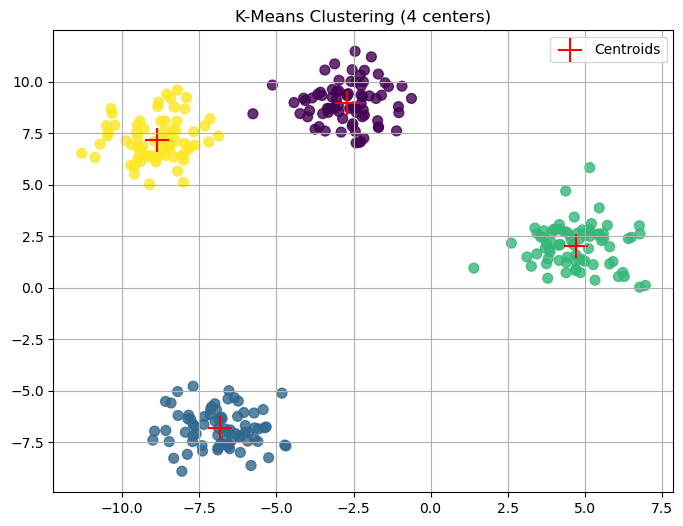

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples=300, centers=4, random_state=42, cluster_std=1.0)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='red', marker='+', label='Centroids')
plt.title('K-Means Clustering (4 centers)')
plt.legend()
plt.grid()
plt.show()

### Q.22. Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10 predicted labels.

In [3]:
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

iris = load_iris()
X = iris.data

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = agg.fit_predict(X)

print("First 10 predicted labels:", labels[:10])

First 10 predicted labels: [1 1 1 1 1 1 1 1 1 1]


### Q.23. Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot.

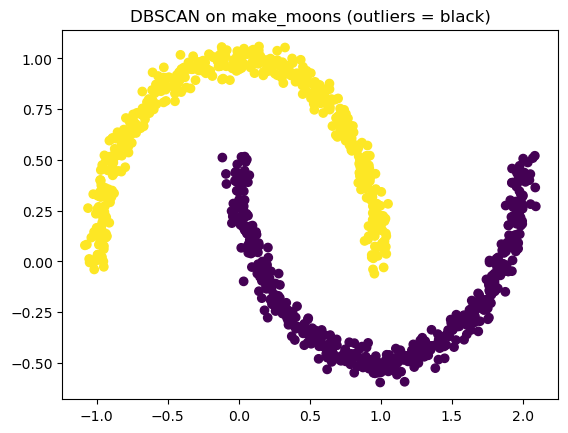

In [4]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

X, y = make_moons(n_samples=1000, noise=0.04, random_state=42)

db = DBSCAN(eps=0.3, min_samples=5)
labels = db.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title('DBSCAN on make_moons (outliers = black)')
plt.show()

### Q.24. Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each cluster.

In [5]:
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X = StandardScaler().fit_transform(wine.data)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

print("Cluster sizes:")
for i in range(3):
    print(f"Cluster {i}: {np.sum(labels == i)} samples")

Cluster sizes:
Cluster 0: 65 samples
Cluster 1: 51 samples
Cluster 2: 62 samples


### Q.25. Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result.

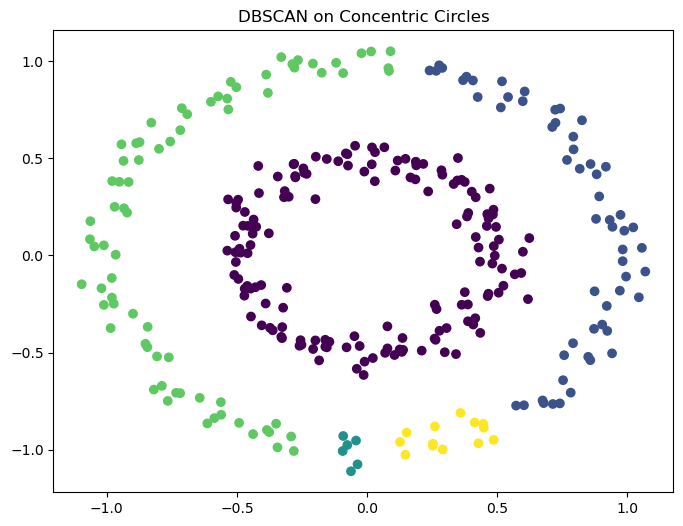

In [6]:
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN

X, y = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

db = DBSCAN(eps=0.15, min_samples=5)
labels = db.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('DBSCAN on Concentric Circles')
plt.show()

### Q.26.  Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster centroids.

In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

data = load_breast_cancer()
X = MinMaxScaler().fit_transform(data.data)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X)

print("Cluster centroids (2 clusters):")
print(kmeans.cluster_centers_)

Cluster centroids (2 clusters):
[[0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]
 [0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]]


### Q.27. Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with DBSCAN.

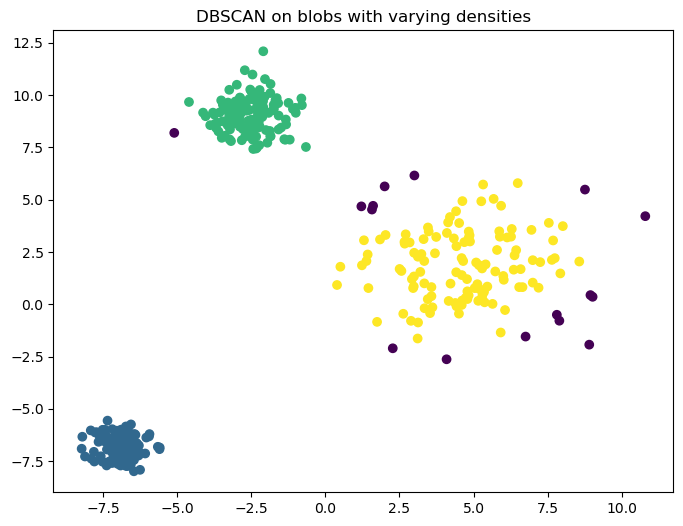

In [8]:
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

X, y = make_blobs(n_samples=400, centers=3, cluster_std=[0.8, 2.0, 0.5], random_state=42)

db = DBSCAN(eps=1.2, min_samples=5)
labels = db.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('DBSCAN on blobs with varying densities')
plt.show()

### Q.28. Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means.

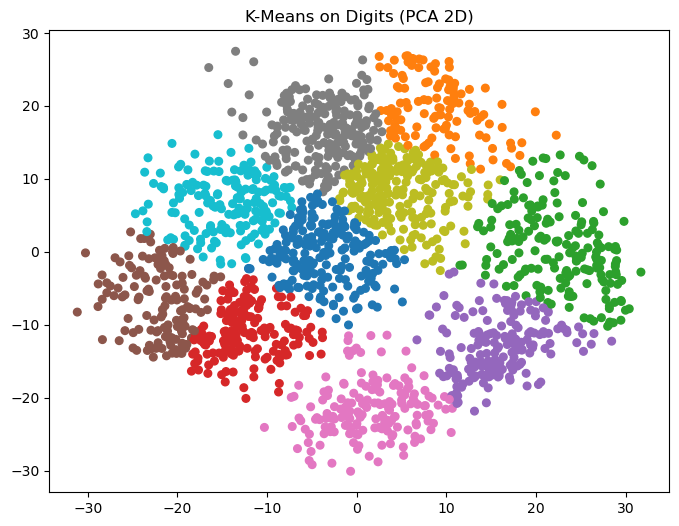

In [9]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

digits = load_digits()
X = digits.data

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_2d)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=30)
plt.title('K-Means on Digits (PCA 2D)')
plt.show()

### Q.29. Create synthetic data using make_blobs and evaluate silhouette scores for k = 2 to 5. Display as a bar chart.

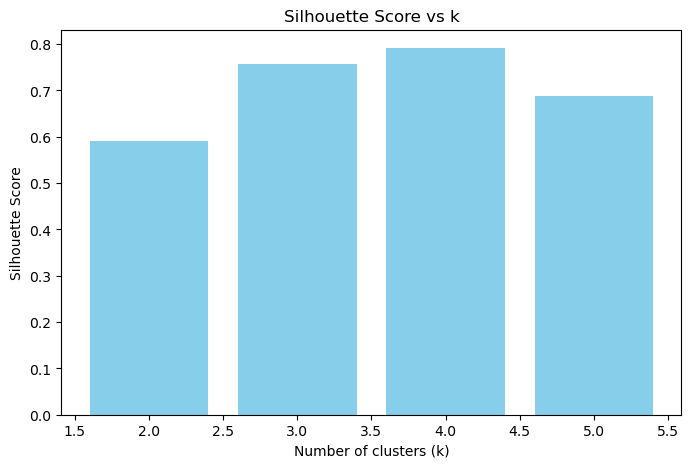

In [10]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, y = make_blobs(n_samples=300, centers=4, random_state=42)

scores = []
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.figure(figsize=(8, 5))
plt.bar(range(2, 6), scores, color='skyblue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs k')
plt.show()

### Q.30. Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage.

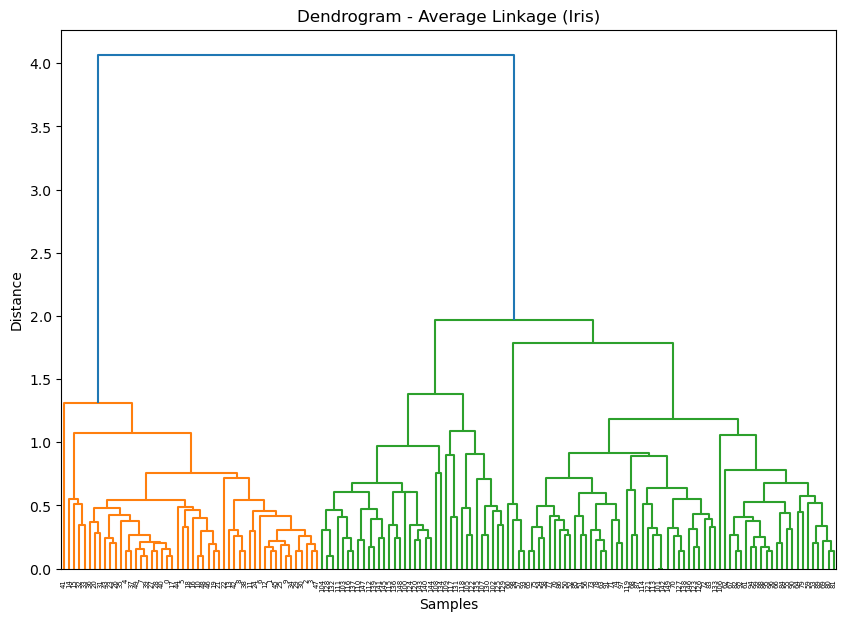

In [11]:
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage

iris = load_iris()
X = iris.data

Z = linkage(X, method='average')

plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Dendrogram - Average Linkage (Iris)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

### Q.31. Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with decision boundaries.

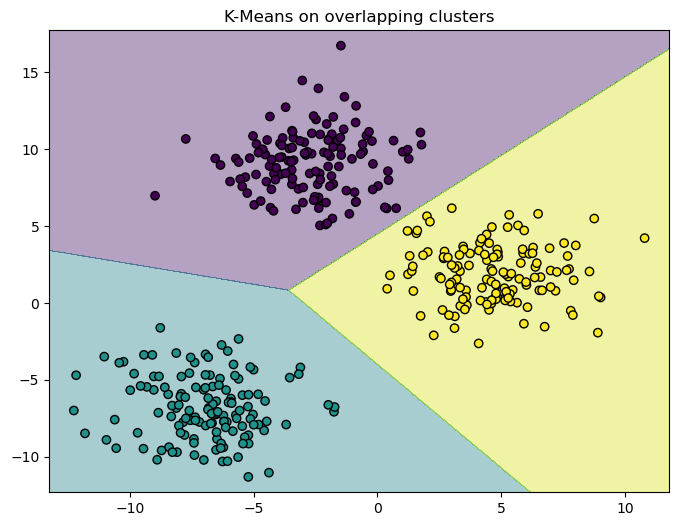

In [12]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples=400, centers=3, cluster_std=2.0, random_state=42)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

h = 0.02
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', edgecolor='k')
plt.title('K-Means on overlapping clusters')
plt.show()

### Q.32. Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results.

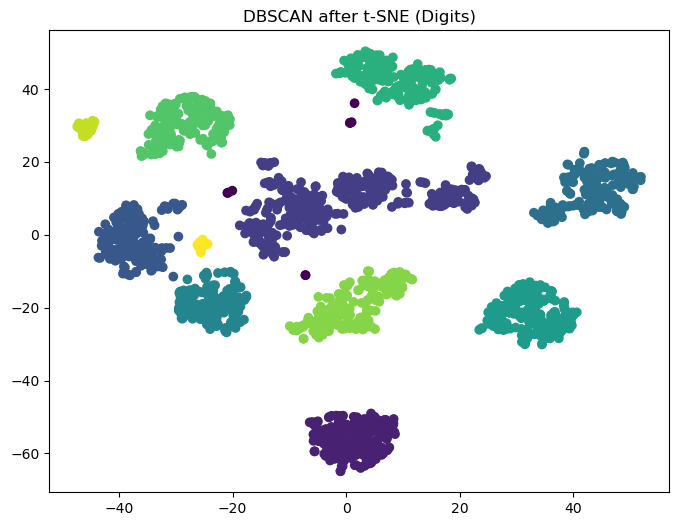

In [13]:
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN

digits = load_digits()
X = digits.data

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

db = DBSCAN(eps=4, min_samples=5)
labels = db.fit_predict(X_tsne)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis')
plt.title('DBSCAN after t-SNE (Digits)')
plt.show()

### Q.33. Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot the result.

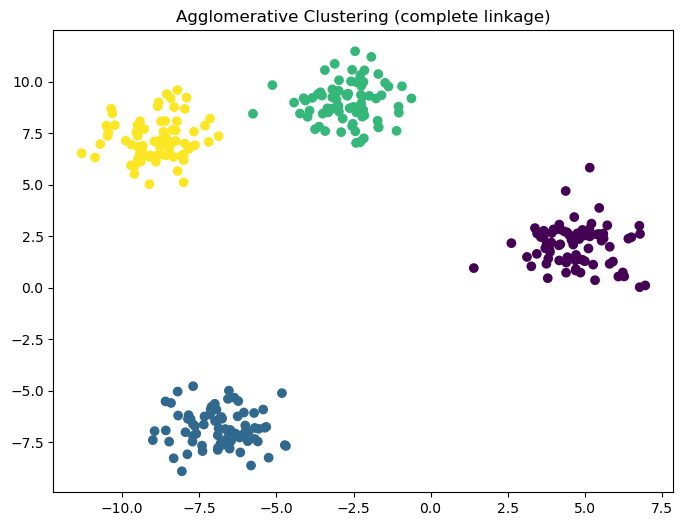

In [14]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

X, y = make_blobs(n_samples=300, centers=4, random_state=42)

agg = AgglomerativeClustering(n_clusters=4, linkage='complete')
labels = agg.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('Agglomerative Clustering (complete linkage)')
plt.show()

### Q.34. Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a line plot.

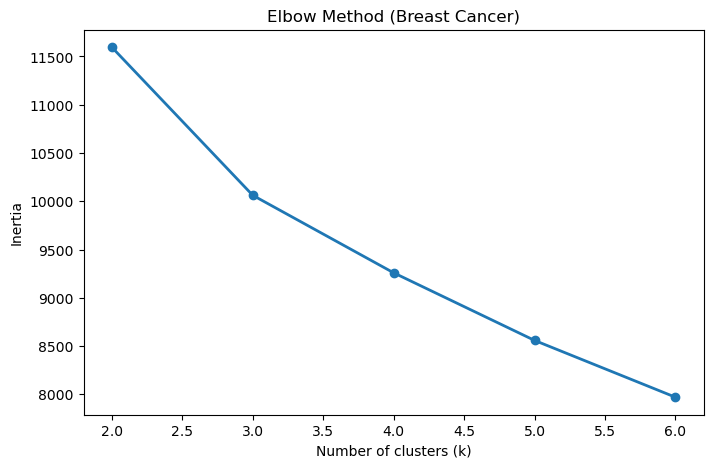

In [15]:
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(load_breast_cancer().data)

inertias = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 7), inertias, marker='o', linewidth=2)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method (Breast Cancer)')
plt.show()

### Q.35. Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with single linkage.

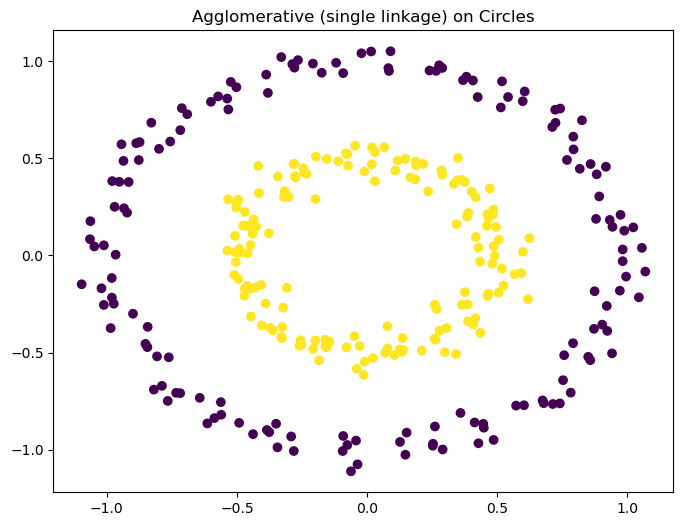

In [16]:
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering

X, y = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

agg = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agg.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('Agglomerative (single linkage) on Circles')
plt.show()

### Q.36. Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise).

In [17]:
from sklearn.datasets import load_wine
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(load_wine().data)

db = DBSCAN(eps=1.8, min_samples=5)
labels = db.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Number of clusters: {n_clusters}")
print(f"Noise points: {n_noise}")

Number of clusters: 7
Noise points: 118


### Q.37.  Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the data points.

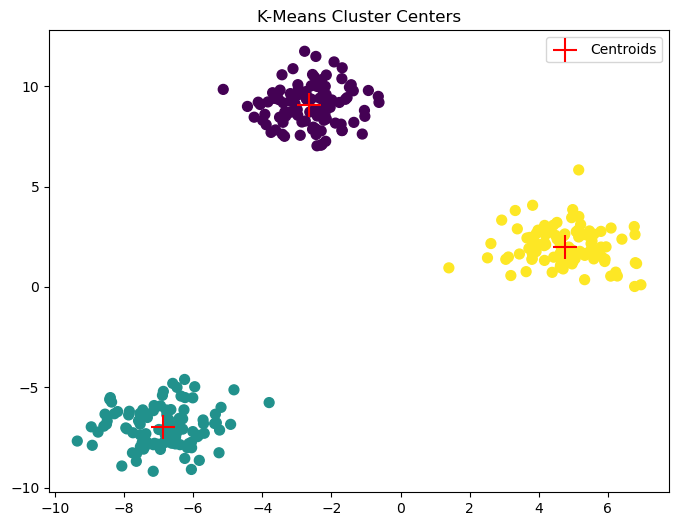

In [18]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples=300, centers=3, random_state=42)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='red', marker='+', label='Centroids')
plt.legend()
plt.title('K-Means Cluster Centers')
plt.show()

### Q.38. Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise.

In [19]:
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(load_iris().data)

db = DBSCAN(eps=0.6, min_samples=5)
labels = db.fit_predict(X)

noise_count = (labels == -1).sum()
print(f"Number of noise samples: {noise_count}")

Number of noise samples: 26


### Q.39. Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the clustering result.

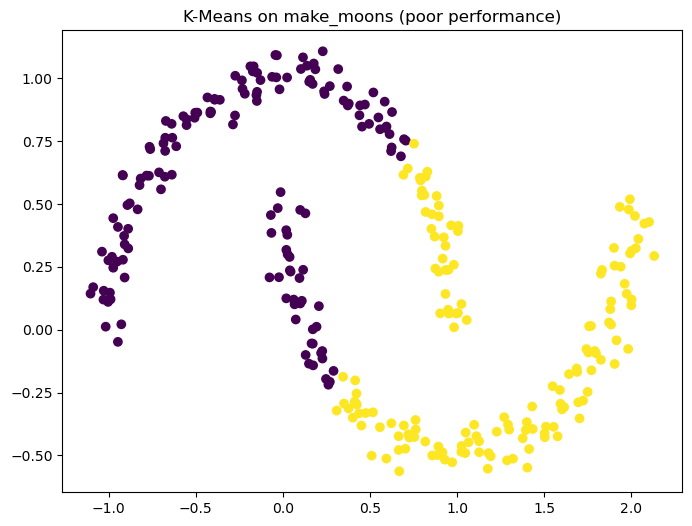

In [20]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('K-Means on make_moons (poor performance)')
plt.show()

### Q.40. Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D scatter plot.

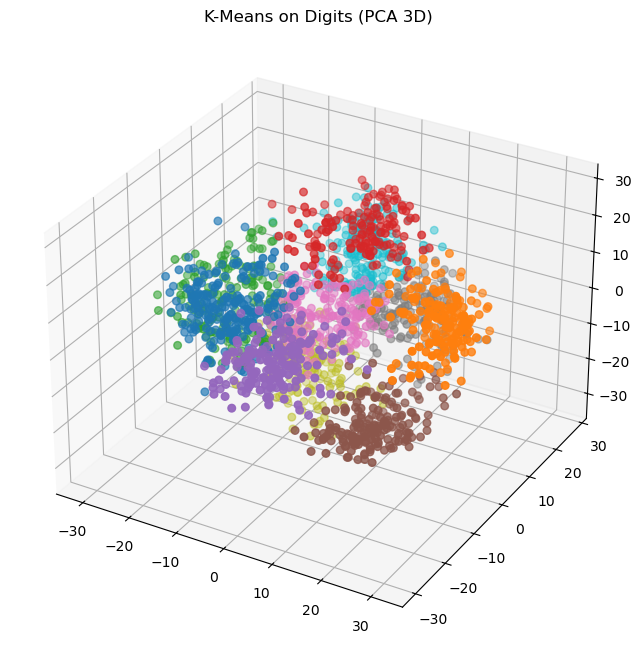

In [21]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

digits = load_digits()
X = digits.data

pca = PCA(n_components=3, random_state=42)
X_3d = pca.fit_transform(X)

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_3d)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=labels, cmap='tab10', s=30)
plt.title('K-Means on Digits (PCA 3D)')
plt.show()

### Q.41. Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the clustering.

In [22]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, y = make_blobs(n_samples=300, centers=5, random_state=42)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

print("Silhouette Score:", round(silhouette_score(X, labels), 4))

Silhouette Score: 0.6586


### Q.42. Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering. Visualize in 2D.

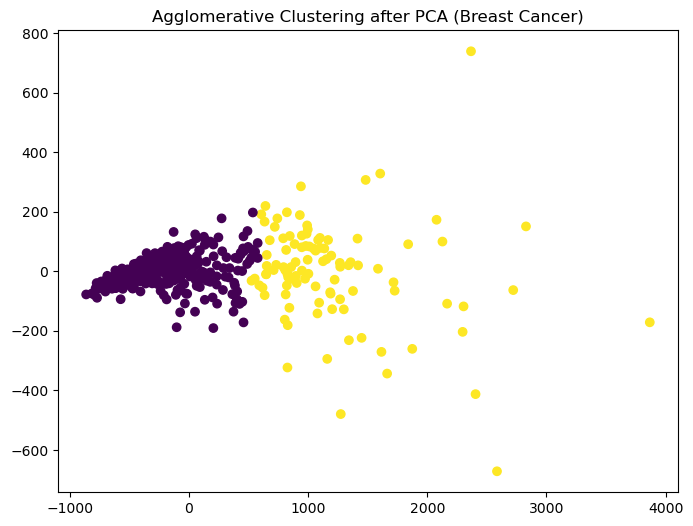

In [23]:
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

X = load_breast_cancer().data
X_2d = PCA(n_components=2, random_state=42).fit_transform(X)

agg = AgglomerativeClustering(n_clusters=2)
labels = agg.fit_predict(X_2d)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis')
plt.title('Agglomerative Clustering after PCA (Breast Cancer)')
plt.show()

### Q.43. Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN side-by-side.

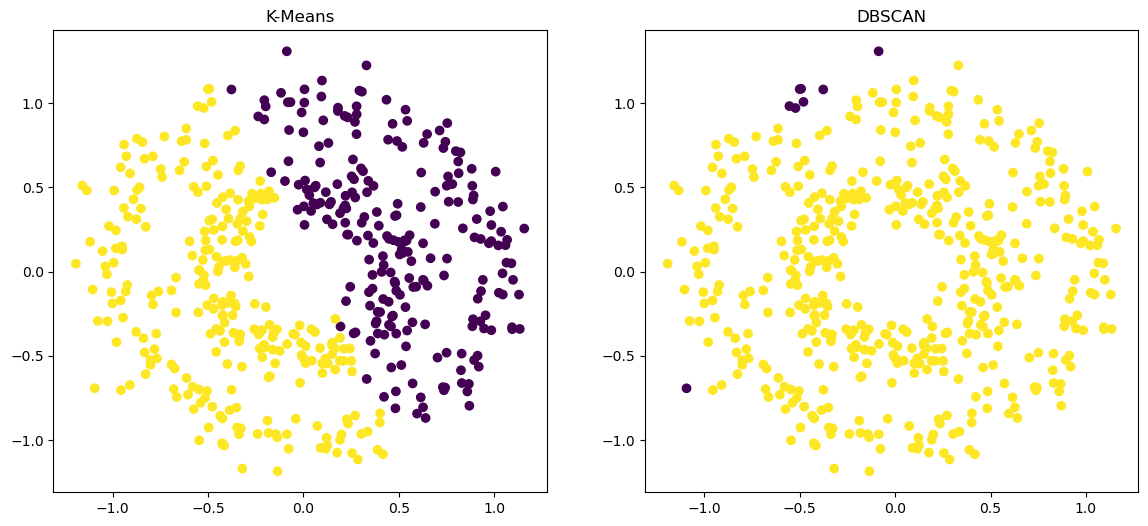

In [24]:
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN

X, y = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X)
dbscan = DBSCAN(eps=0.2, min_samples=10).fit_predict(X)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].scatter(X[:, 0], X[:, 1], c=kmeans, cmap='viridis')
axs[0].set_title('K-Means')
axs[1].scatter(X[:, 0], X[:, 1], c=dbscan, cmap='viridis')
axs[1].set_title('DBSCAN')
plt.show()

### Q.44. Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering.

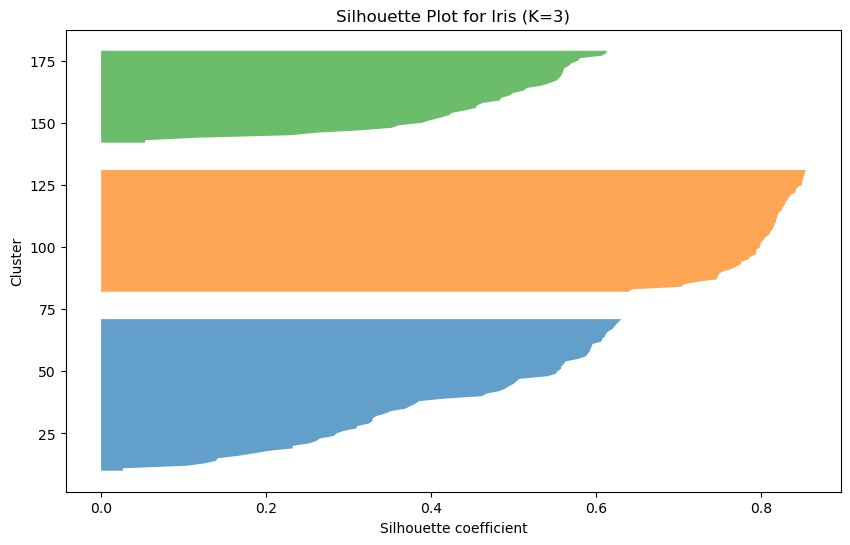

In [25]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples

X = load_iris().data
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

sil_vals = silhouette_samples(X, labels)

plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(3):
    cluster_sil = sil_vals[labels == i]
    cluster_sil.sort()
    size = cluster_sil.shape[0]
    y_upper = y_lower + size
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7)
    y_lower = y_upper + 10

plt.title('Silhouette Plot for Iris (K=3)')
plt.xlabel('Silhouette coefficient')
plt.ylabel('Cluster')
plt.show()

### Q.45. Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage. Visualize clusters.

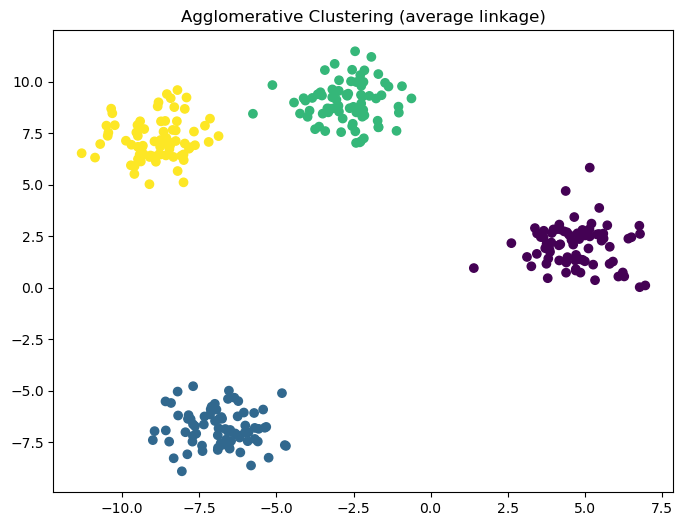

In [26]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

agg = AgglomerativeClustering(n_clusters=4, linkage='average')
labels = agg.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('Agglomerative Clustering (average linkage)')
plt.show()

### Q.46. Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4 features).

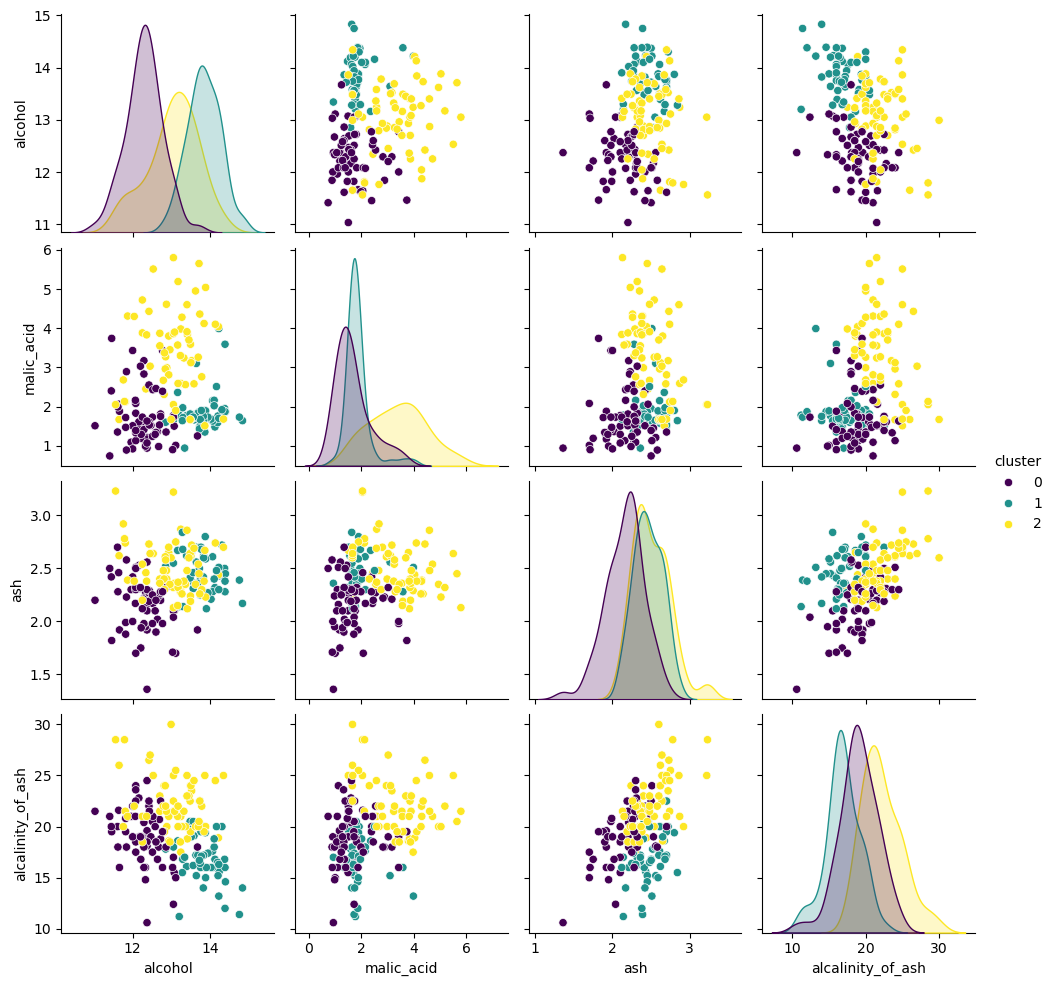

In [27]:
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

wine = load_wine()
df = pd.DataFrame(wine.data[:, :4], columns=wine.feature_names[:4])

X_scaled = StandardScaler().fit_transform(df)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

sns.pairplot(df, hue='cluster', palette='viridis')
plt.show()

### Q.47. Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the count.

In [28]:
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

X, _ = make_blobs(n_samples=500, centers=3, cluster_std=1.2, random_state=42)

db = DBSCAN(eps=0.8, min_samples=6)
labels = db.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise}")

Clusters found: 3
Noise points: 25


### Q.48. Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the clusters.

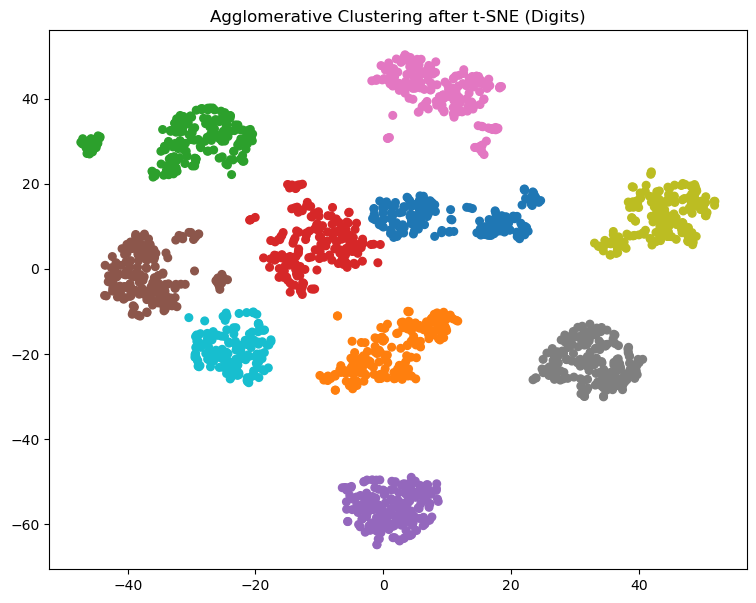

In [29]:
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering

digits = load_digits()
X = digits.data

X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X)

agg = AgglomerativeClustering(n_clusters=10)
labels = agg.fit_predict(X_tsne)

plt.figure(figsize=(9, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=30)
plt.title('Agglomerative Clustering after t-SNE (Digits)')
plt.show()